# Plot: patient x treatment response heatmap

Same per-patient coefficient table, rolled up into a count of significant features per (patient, drug) pair.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from notebook_init_utils import init_notebook

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

figures_path = pathlib.Path(
    root_dir, "4.linear_modeling/figures/per_patient_variate_importance"
)
figures_path.mkdir(parents=True, exist_ok=True)
results_path = pathlib.Path(
    root_dir, "4.linear_modeling/results/per_patient_variate_importance"
)

PVALUE_MAX = 0.05


def load_coefficients(profile_name):
    df = pd.read_parquet(
        results_path / f"{profile_name}_per_patient_coefficients.parquet"
    )
    df["significant"] = df["pvalue_fdr"] < PVALUE_MAX
    return df


coef_dfs = {name: load_coefficients(name) for name in ["organoid", "single_cell"]}

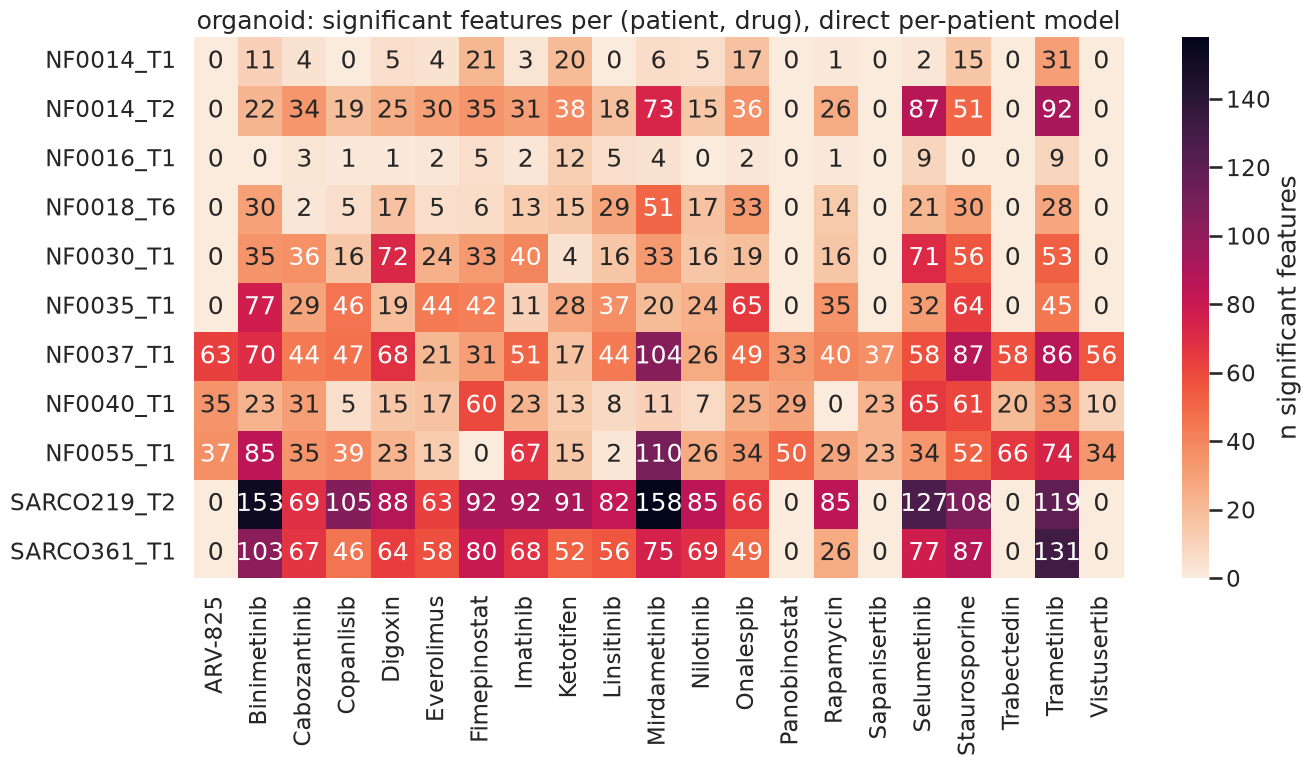

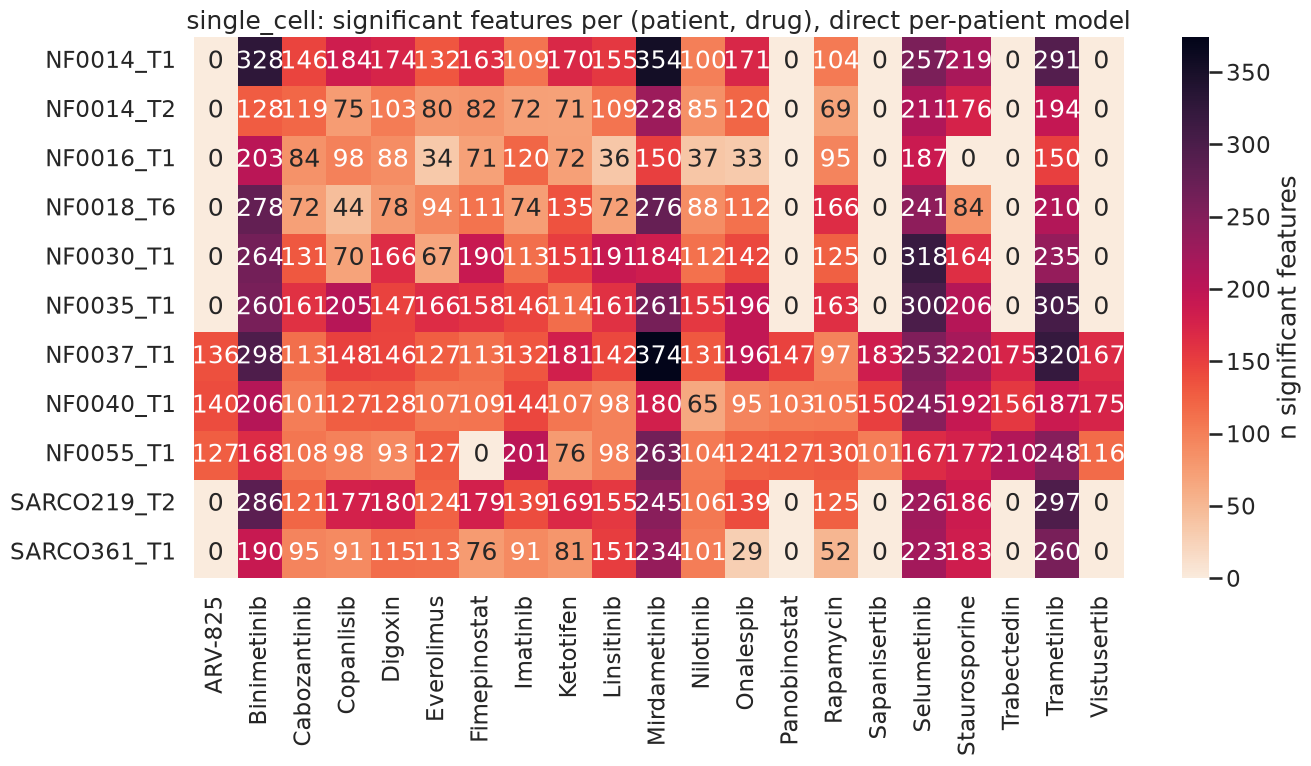

In [2]:
def plot_patient_treatment_heatmap(df, name):
    counts = (
        df[df["significant"]]
        .groupby(["patient", "drug"])
        .size()
        .reset_index(name="n_significant_features")
        .pivot(index="patient", columns="drug", values="n_significant_features")
        .fillna(0)
    )
    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(
        counts,
        annot=True,
        fmt=".0f",
        cmap="rocket_r",
        ax=ax,
        cbar_kws={"label": "n significant features"},
    )
    ax.set_title(
        f"{name}: significant features per (patient, drug), direct per-patient model"
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(
        figures_path / f"{name}_patient_treatment_heatmap.png",
        dpi=600,
        bbox_inches="tight",
    )
    plt.show()


for name, df in coef_dfs.items():
    plot_patient_treatment_heatmap(df, name)

Rows with many dark cells are broadly treatment-responsive patients; columns with many dark cells are broadly active drugs — directly comparable to the breadth analysis in `explore_leads.ipynb`.